# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("../dataset_raw/student_stress.csv")
df.head()

,Student_ID,Gender,Age,Semester,Study_Hours_Per_Day,Assignment_Load,Sleep_Hours,Attendance_Percentage,Screen_Time_Hours,Caffeine_Intake,Extracurricular_Hours,Exam_Pressure,Financial_Stress,Social_Support,Stress_Level
0,S001,Male,18,5,6.0,4,6.3,79,8.3,1,5,2,9,2,Medium
1,S002,Female,18,1,8.0,2,6.1,78,6.5,1,4,10,1,9,Low
2,S003,Male,23,7,8.2,4,7.7,93,6.1,4,2,1,3,7,Low
3,S004,Female,20,3,6.1,4,5.8,86,6.1,0,0,7,2,6,Medium
4,S005,Female,22,5,5.5,1,3.6,94,3.6,4,0,7,2,9,Low


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.isnull().sum()

Student_ID               0
Gender                   0
Age                      0
Semester                 0
Study_Hours_Per_Day      0
Assignment_Load          0
Sleep_Hours              0
Attendance_Percentage    0
Screen_Time_Hours        0
Caffeine_Intake          0
Extracurricular_Hours    0
Exam_Pressure            0
Financial_Stress         0
Social_Support           0
Stress_Level             0
dtype: int64

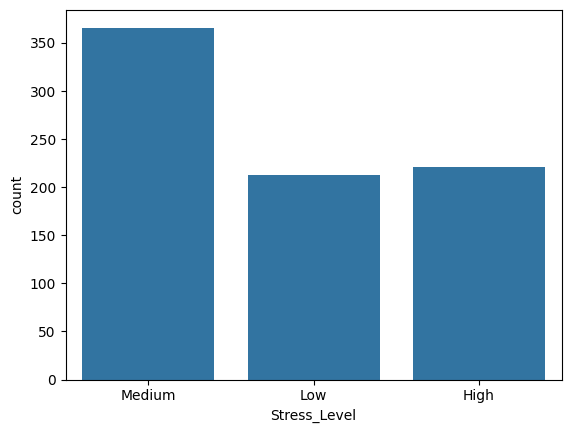

In [4]:
sns.countplot(
    x="Stress_Level",
    data=df
)

plt.show()

In [5]:
df["Stress_Level"].value_counts().sort_index()

Stress_Level
High      221
Low       213
Medium    366
Name: count, dtype: int64

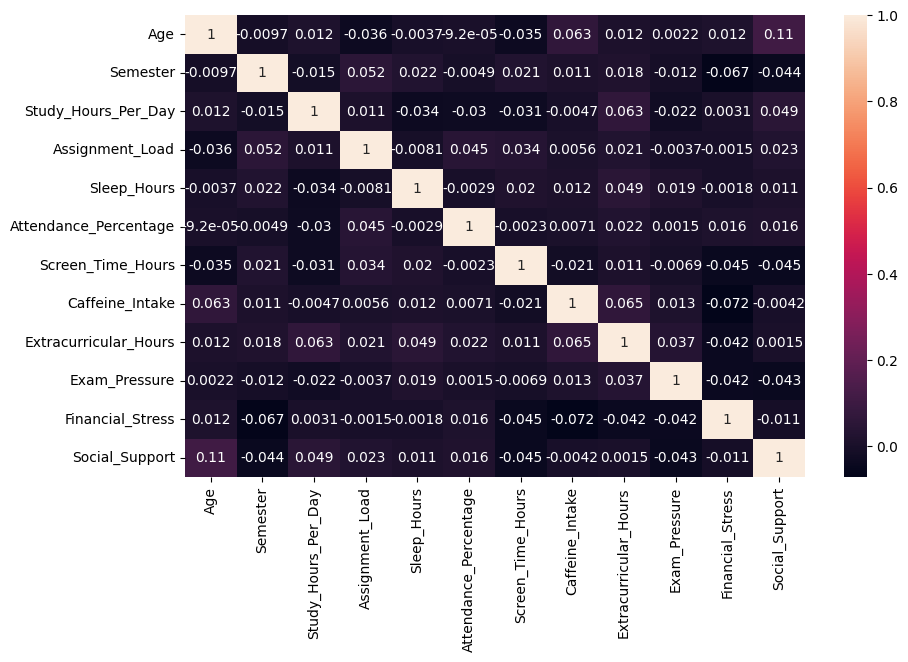

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [7]:
print("\n--- Informasi Kolom dan Tipe Data ---")
print(df.info())
print("\n--- Pengecekan Data Kosong ---")
print(df.isnull().sum())
print("\n--- Distribusi Target Kelas Stress ---")
print(df['Stress_Level'].value_counts())


--- Informasi Kolom dan Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             800 non-null    object 
 1   Gender                 800 non-null    object 
 2   Age                    800 non-null    int64  
 3   Semester               800 non-null    int64  
 4   Study_Hours_Per_Day    800 non-null    float64
 5   Assignment_Load        800 non-null    int64  
 6   Sleep_Hours            800 non-null    float64
 7   Attendance_Percentage  800 non-null    int64  
 8   Screen_Time_Hours      800 non-null    float64
 9   Caffeine_Intake        800 non-null    int64  
 10  Extracurricular_Hours  800 non-null    int64  
 11  Exam_Pressure          800 non-null    int64  
 12  Financial_Stress       800 non-null    int64  
 13  Social_Support         800 non-null    int64  
 14  Stress_Level       

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop(columns=['Student_ID', 'Stress_Level'])
y = df['Stress_Level']

le_gender = LabelEncoder()
X['Gender'] = le_gender.fit_transform(X['Gender'])

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

cleaned_df = pd.DataFrame(X_scaled, columns=X.columns)
cleaned_df['target'] = y_encoded

os.makedirs('namadataset_preprocessing', exist_ok=True)

cleaned_df.to_csv(
    'namadataset_preprocessing/student_stress_cleaned.csv',
    index=False
)

print("\n[+] Tahap Eksperimen Preprocessing Selesai Dilakukan!")


[+] Tahap Eksperimen Preprocessing Selesai Dilakukan!
